In [71]:
import numpy as np
import pandas as pd

In [72]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/main/data/reddit.csv"
)

In [73]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [74]:
df.shape

(37249, 2)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [76]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [77]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [78]:
df[df['clean_comment'].isna()]['category'].value_counts()

,count
category,
0,100


In [79]:
df.dropna(inplace=True)

In [80]:
df.duplicated().sum()

np.int64(350)

In [81]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [82]:
df.drop_duplicates(inplace=True)

In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
df[(df['clean_comment'].str.strip()=='')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [85]:
df[~(df['clean_comment'].str.strip()=='')]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [86]:
# To lowercase
df['clean_comment']=df['clean_comment'].str.lower()

# Verify
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [87]:
df[df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [88]:
# Identify comments containing URL
url_pattern=r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls=df[df['clean_comment'].str.contains(url_pattern,regex=True)]

# Display the comments containing URLs
comments_with_urls.head()

,clean_comment,category


In [89]:
# Remove new line characters from the 'clean_comment' column
df['clean_comment']=df['clean_comment'].str.replace('\n',' ',regex=True)

# Verify
comments_with_newline_remaining=df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


**understanding your dataset before building a model : EDA**

<Axes: xlabel='category', ylabel='count'>

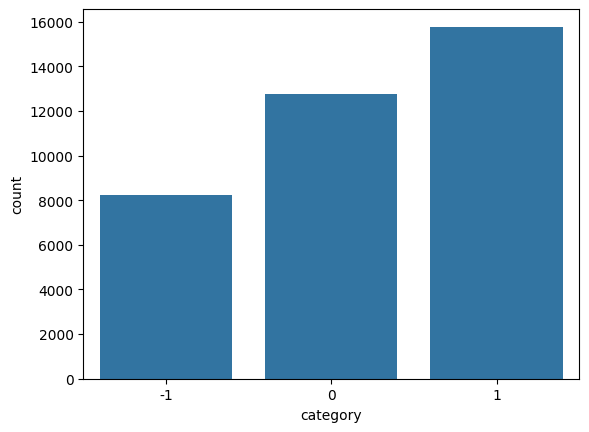

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

# distribution of classes

sns.countplot(data=df,x='category')

In [91]:
# frequency distribution of sentiments

df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.72
-1,22.42


In [92]:
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))

In [93]:
df.sample(5)

,clean_comment,category,word_count
12976,owaisi sounds much saner than bjp goons someti...,1,8
32375,yeh toh international media mein bhi chhap gaya,0,8
21347,welcome fellow pinoy haven gifted receive any ...,1,15
37173,catch people with white money has decided dem...,0,9
5078,thread has been rediquette enforced upon request,0,7


In [94]:
df['word_count'].describe()

,word_count
count,36799.000000
mean,29.662627
std,56.787371
min,0.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


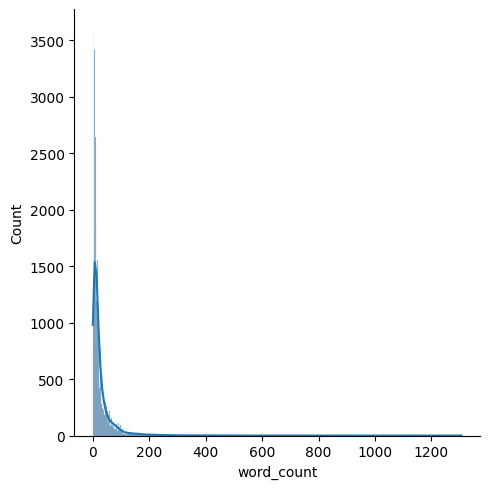

In [95]:
sns.displot(df['word_count'],kde=True)

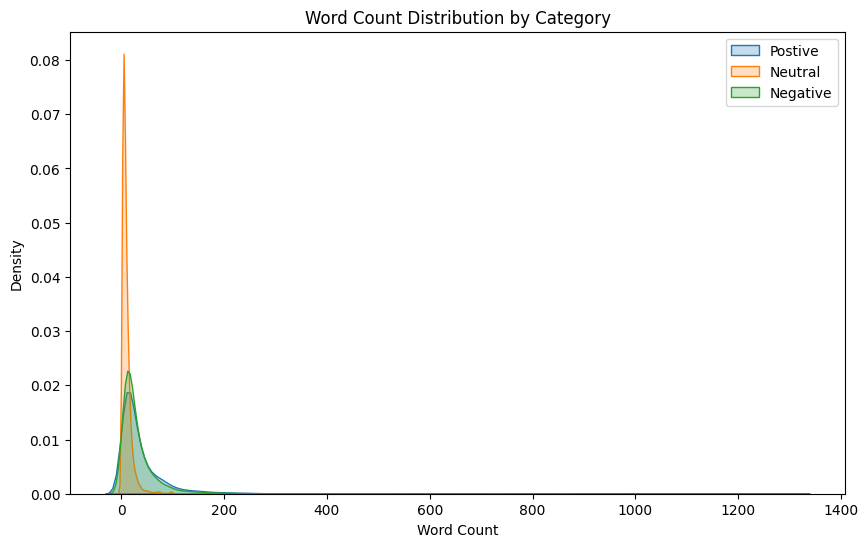

In [96]:
# Create the figure
plt.figure(figsize=(10,6))

# Plot KDE for category 1
sns.kdeplot(df[df['category']==1]['word_count'],label='Postive',fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category']==0]['word_count'],label='Neutral',fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category']==-1]['word_count'],label='Negative',fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

plt.legend()
plt.show()

**Postive comments(category 1)**: These tend to have a wider spread in word count, indicating that longer comments are more common in postive sentiments.

**Neural comments (category 0)**: The distribution shows a relatively lower frequency and is more concentrated around shorter comments compared to positive or negative ones.

**Negative comments (category -1)**: These comments have a distribution some what similar to positive comments but with a smaller proportion of longer comments

<Axes: ylabel='word_count'>

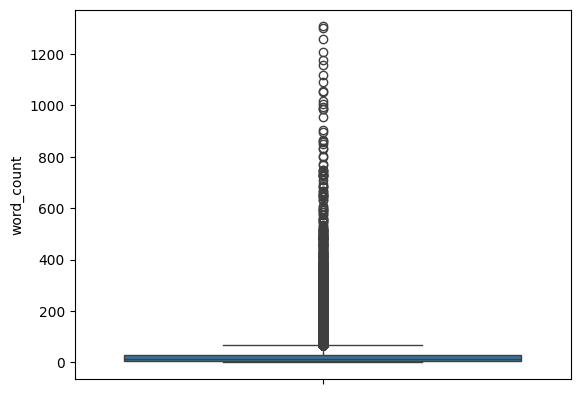

In [97]:
sns.boxplot(df['word_count'])

**Most texts are short**: The box (middle part) is very close to the bottom (near 0–50 words roughly).This means most comments have a small number of words.

**Strong right-skewed distribution**: There are many points going far upward (outliers), reaching 1000+ words.This means a small number of texts are extremely long, while most are short.

**Many outliers**: The dots above the box are outliers.So your dataset contains:
a few very long texts (200 → 1300 words)
but they are rare compared to normal ones

**Median is low**: The line inside the box (median) is low. Half of your data is below a small word count → again confirms most texts are short.

**Highly imbalanced in length (many short texts + few very long ones)**

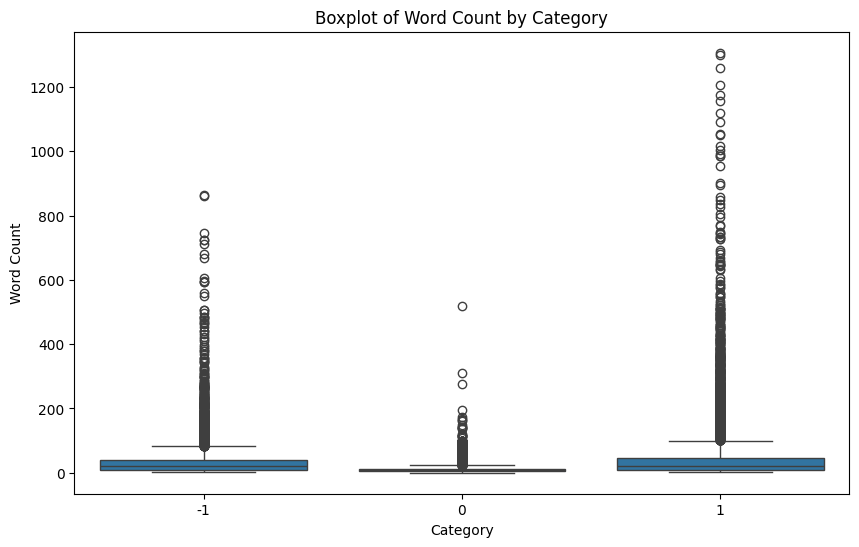

In [98]:
# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='category',y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Postive comments (category 1)**: The median word count is relatively high and there are several outliers with longer comments, indicating that postive comments tend to be more verbose

**Neural comments (category 0)**:The median word count is the lowest,with a tighter interquartile range(IQR),suggesting that neutral comments are generally shorter

**Negative comments (category -1)**:The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers

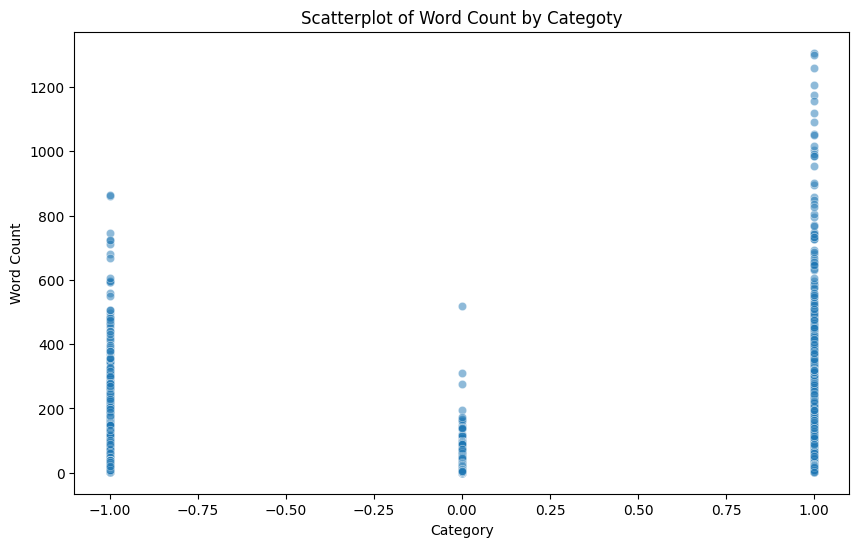

In [99]:
# Create a scatterplot between 'category' and 'wordcount'
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='category',y='word_count',alpha=0.5)
plt.title('Scatterplot of Word Count by Categoty')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Used to check**:

-See how word length varies across categories

-Detect patterns or differences

-Identify imbalance or behavior

<Axes: xlabel='category', ylabel='word_count'>

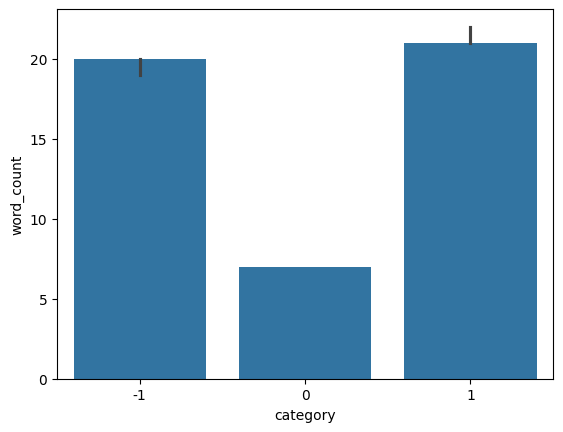

In [100]:
# median word counts among sentiments

sns.barplot(df,x="category",y='word_count',estimator='median')

In [101]:
!pip install nltk

In [102]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
import nltk
nltk.download('stopwords')

# Define the list of English stopwords
stop_words=set(stopwords.words('english'))

# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words']=df['clean_comment'].apply(lambda x:len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [103]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
15764,trying pay 30rs for the game for the name the...,-1,12,5
1418,here take india was partitioned belief that mu...,1,179,64
25376,ambanis aur adani choukidaar waahmodijiwaah,0,5,0
19137,congress support bjp hmm don think this case s...,-1,102,33
4735,man this has the most unnecessary controversy...,1,53,19


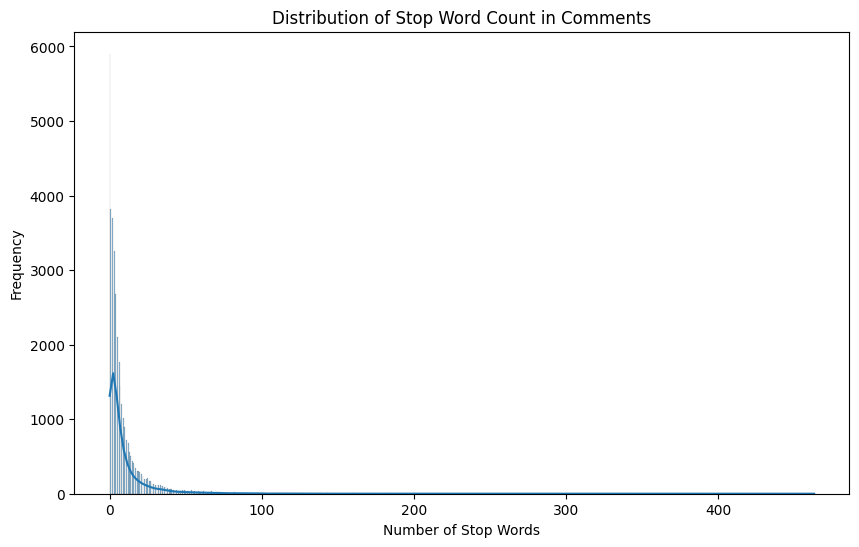

In [104]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10,6))
sns.histplot(df["num_stop_words"],kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

**Main observation**:

-The distribution is highly skewed to the right

-The majority of comments contain very few stop words (around 0 to ~20)

-Very few comments contain a large number of stop words

-There is a long tail extending up to ~400+

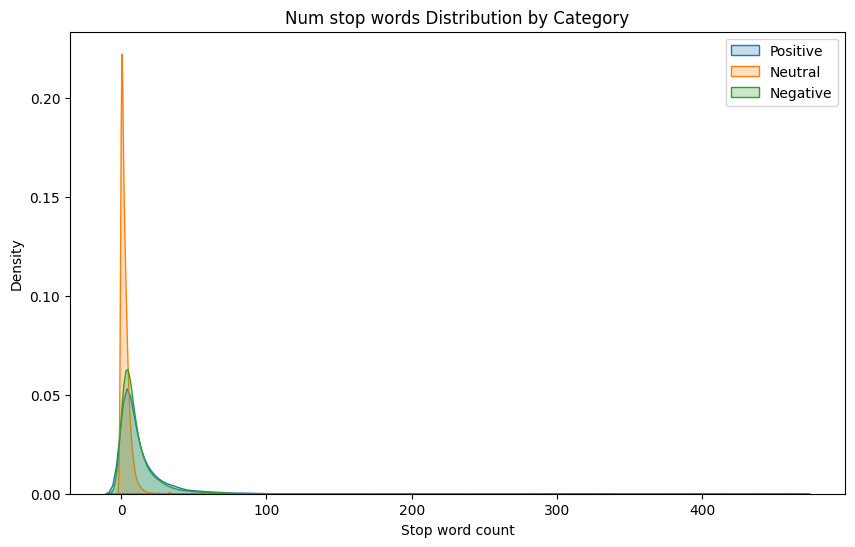

In [105]:
# Create the figure and axes
plt.figure(figsize=(10,6))

# Plot KDE for category 1
sns.kdeplot(df[df['category']==1]['num_stop_words'],label='Positive',fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category']==0]['num_stop_words'],label='Neutral',fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category']==-1]['num_stop_words'],label='Negative',fill=True)

# Add title and labels
plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

# Add a legend
plt.legend()
plt.show()

**Conclusion**

-Neutral comments are generally short and simple

-Positive and negative comments are longer and more detailed

-There is a significant overlap between positive and negative comments

-A discriminative variable is a variable that helps separate classes

-A discriminative variable is a variable that helps separate classes

<Axes: xlabel='category', ylabel='num_stop_words'>

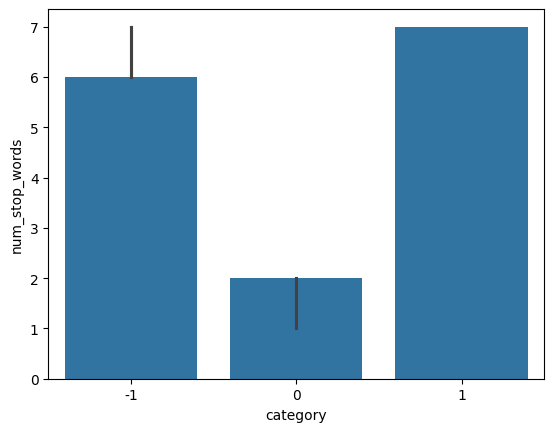

In [106]:
# median word counts among sentiments

sns.barplot(df,x='category',y='num_stop_words',estimator='median')

**Key Takeaways**

-Positive texts (1) use the most stop words — median of ~7, and notably have no error bar, meaning very consistent stop word usage across samples.

-Negative texts (-1) are close behind — median of ~6, but with a visible error bar indicating some variability.

-Neutral texts (0) use far fewer stop words — median of only ~2, with the most variability (largest error bar).

/tmp/ipykernel_683/1653202871.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df,x='count',y='stop_word',palette='viridis')


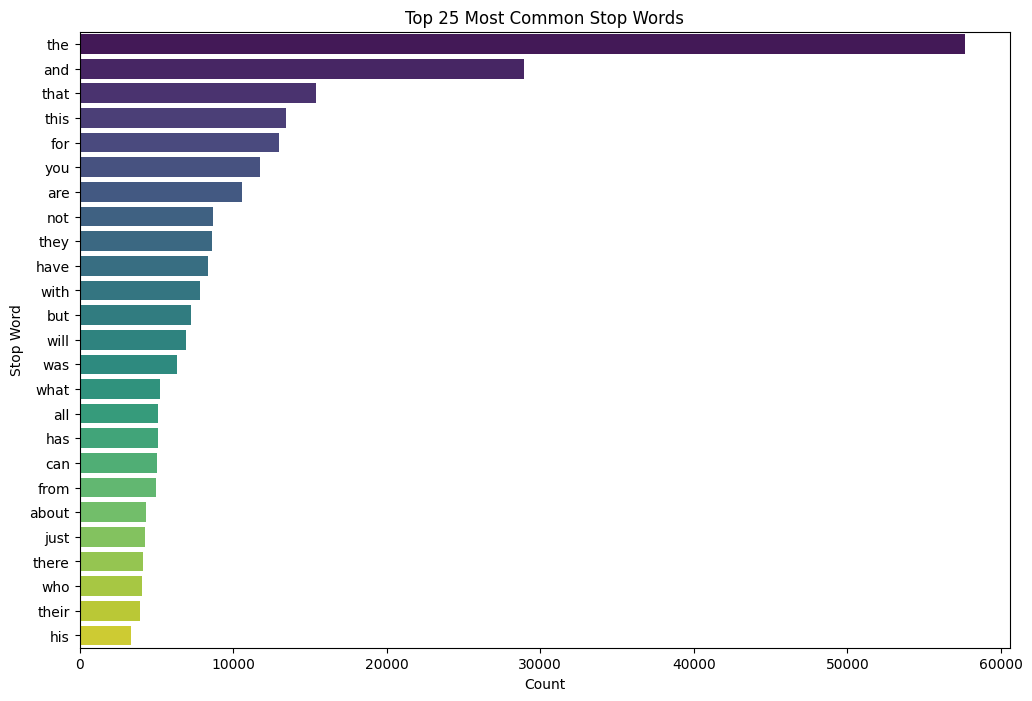

In [107]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words=[word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

# Count the most common stop words
most_common_stop_words=Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df=pd.DataFrame(most_common_stop_words,columns=["stop_word",'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df,x='count',y='stop_word',palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()


In [108]:
df['num_chars']=df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them t...,1,39,13,261
1,buddhism has very much lot compatible with chr...,1,196,59,1269
2,seriously don say thing first all they won get...,-1,86,40,460
3,what you have learned yours and only yours wha...,0,29,15,168
4,for your own benefit you may want read living ...,1,112,45,691


In [109]:
df['num_chars'].describe()

,num_chars
count,36799.000000
mean,182.988723
std,359.748173
min,1.000000
25%,39.000000
50%,81.000000
75%,185.500000
max,8665.000000


In [110]:
from collections import Counter

# Combine all comments into one large string
all_text=' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency=Counter(all_text)

# Convert the caracter frequency into a DataFrame for better display
char_frequency_df=pd.DataFrame(char_frequency.items(),columns=['character','frequency']).sort_values(by='frequency')

In [111]:
char_frequency_df['character'].values

array(['∀', '￼', 'ಳ', ..., 't', 'e', ' '], dtype=object)

In [112]:
char_frequency_df.tail(50)

,character,frequency
66,ि,232
456,ė,280
72,्,285
71,ो,305
67,ं,325
98,@,366
69,ी,394
60,\,463
68,े,519
57,”,665


In [113]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars']=df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
17682,justice department needs shut down the former ...,-1,15,5,106,0
18513,case uidai wants carrying fresh urine sample ...,1,32,8,215,0
18846,yes know there was like threads about india no...,0,18,7,107,0
15277,this photoshopped you anti nationalist get rea...,1,8,2,56,0
18238,thought spiritual practices agree with yourse...,-1,21,7,139,0


In [114]:
df['num_punctuation_chars'].describe()

,num_punctuation_chars
count,36799.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


/tmp/ipykernel_683/475216275.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='Blues_r')


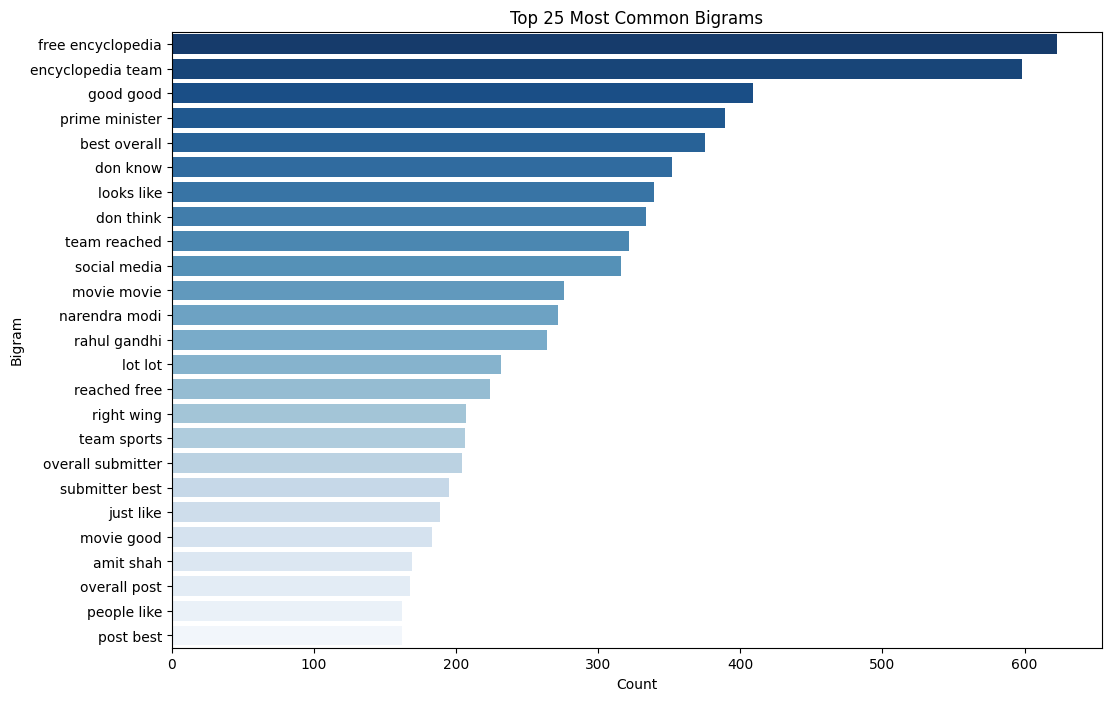

In [115]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus,n=None):
  vec=CountVectorizer(ngram_range=(2,2),stop_words='english').fit(corpus)
  bag_of_words=vec.transform(corpus)
  sum_words=bag_of_words.sum(axis=0)
  words_freq=[(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
  words_freq=sorted(words_freq,key=lambda x: x[1],reverse=True)
  return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams=get_top_ngrams(df['clean_comment'],25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df=pd.DataFrame(top_25_bigrams,columns=['bigram','count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='Blues_r')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

/tmp/ipykernel_683/239572092.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='Blues_r')


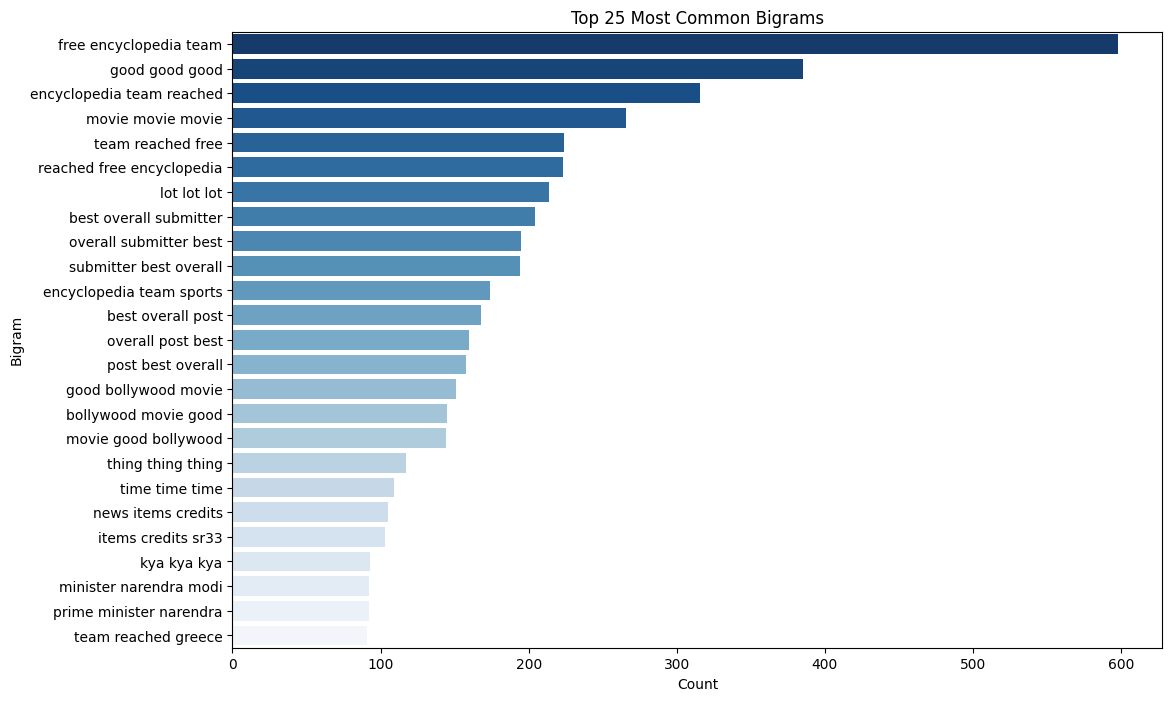

In [116]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus,n=None):
  vec=CountVectorizer(ngram_range=(3,3),stop_words='english').fit(corpus)
  bag_of_words=vec.transform(corpus)
  sum_words=bag_of_words.sum(axis=0)
  words_freq=[(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
  words_freq=sorted(words_freq,key=lambda x: x[1],reverse=True)
  return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams=get_top_ngrams(df['clean_comment'],25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df=pd.DataFrame(top_25_bigrams,columns=['bigram','count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='Blues_r')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

In [117]:
# Remove non-English characters from the 'clean_comment' column
# Retain only English letters, numbers, and common punctuation marks
import re

df['clean_comment']=df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]','',str(x)))

In [118]:
all_text=' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency=Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df=pd.DataFrame(char_frequency.items(),columns=['character','frequency']).sort_values(by='frequency')

char_frequency_df

,character,frequency
39,,1
40,,3
37,\t,11
38,,76
33,8,1199
36,7,1291
28,6,1403
29,4,1573
35,3,1617
27,5,1631


In [119]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them t...,1,39,13,261,0
1,buddhism has very much lot compatible with chr...,1,196,59,1269,0
2,seriously don say thing first all they won get...,-1,86,40,460,0
3,what you have learned yours and only yours wha...,0,29,15,168,0
4,for your own benefit you may want read living ...,1,112,45,691,0


In [120]:
from nltk.corpus import stopwords

# Create a stop word list and preserve words that carry sentiment information
stop_words=set(stopwords.words('english'))-{'not','but','however','no','yet'}

# Remove stop words from 'clean_comment' columns
df['clean_comment']=df['clean_comment'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]))

In [121]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,261,0
1,buddhism much lot compatible christianity espe...,1,196,59,1269,0
2,seriously say thing first get complex explain ...,-1,86,40,460,0
3,learned want teach different focus goal not wr...,0,29,15,168,0
4,benefit may want read living buddha living chr...,1,112,45,691,0


In [122]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer=WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment']=df['clean_comment'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,261,0
1,buddhism much lot compatible christianity espe...,1,196,59,1269,0
2,seriously say thing first get complex explain ...,-1,86,40,460,0
3,learned want teach different focus goal not wr...,0,29,15,168,0
4,benefit may want read living buddha living chr...,1,112,45,691,0


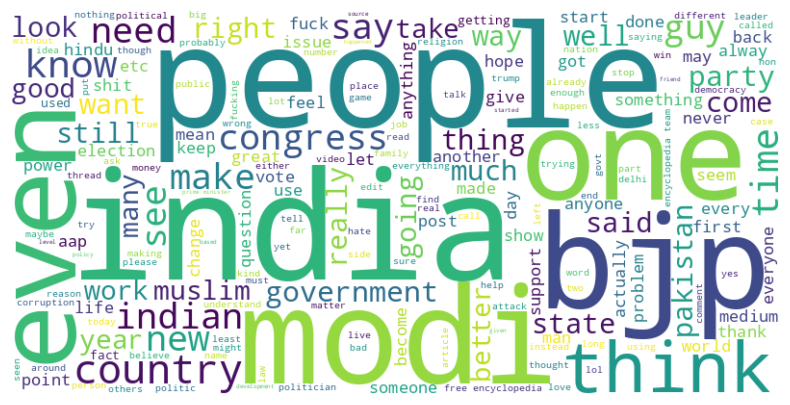

In [123]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
  wordcloud=WordCloud(width=800,height=400,background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud,interpolation='bilinear')
  plt.axis('off')
  plt.show()

plot_word_cloud(df["clean_comment"])

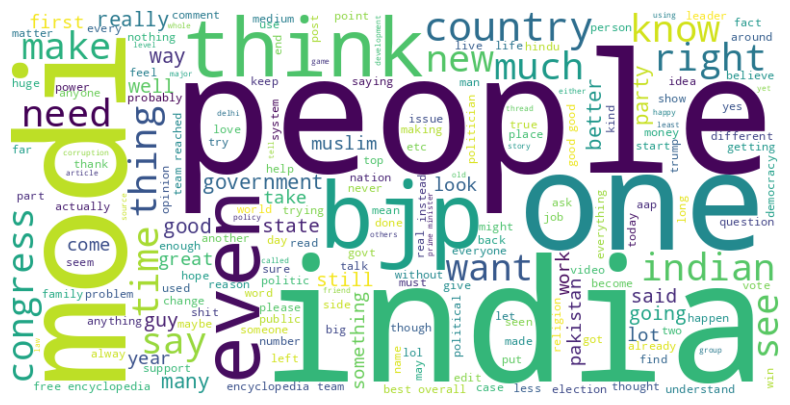

In [124]:
plot_word_cloud(df[df['category']==1]["clean_comment"])

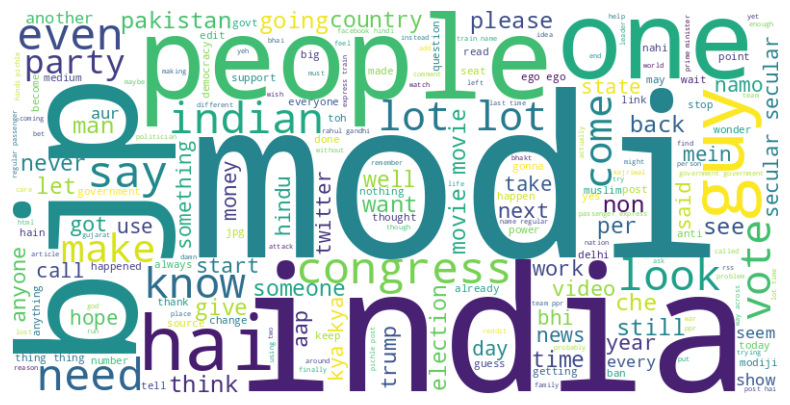

In [125]:
plot_word_cloud(df[df['category']==0]["clean_comment"])

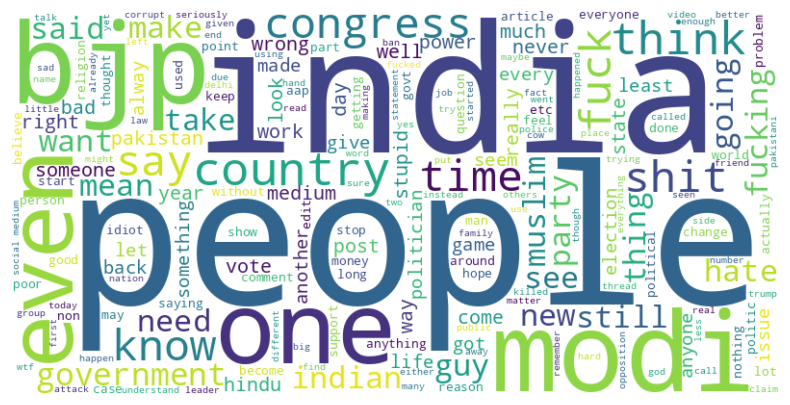

In [126]:
plot_word_cloud(df[df['category']==-1]["clean_comment"])

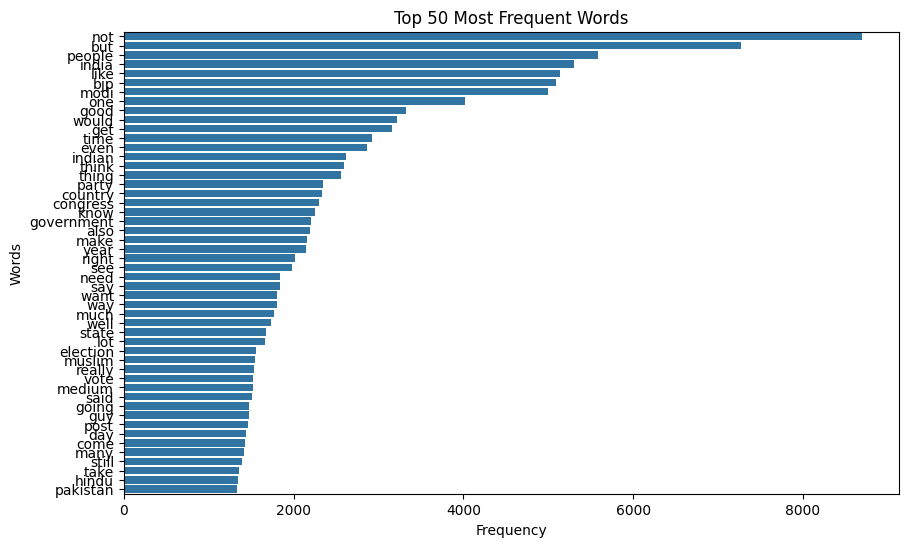

In [128]:
def plot_top_n_words(df,n=20):
  """"Plot the top N most frequent words in the dataset"""
  # all words in the content
  words=' '.join(df['clean_comment']).split()

  # Get the top N most common words
  counter=Counter(words)
  most_common_words=counter.most_common(n)

  # Split the words and their counts for plotting
  words,counts=zip(*most_common_words)

  # Plot the top N words
  plt.figure(figsize=(10,6))
  sns.barplot(x=list(counts),y=list(words))
  plt.title(f'Top {n} Most Frequent Words')
  plt.xlabel('Frequency')
  plt.ylabel('Words')
  plt.show()

# Example usage
plot_top_n_words(df,n=50)
